# 06 — Radiation Suppression & Diurnal Temperature Range

## Hypothesis

Wildfire smoke **scatters and absorbs incoming solar radiation**, reducing the energy available
to heat the surface during daylight hours. This produces a measurable compression of the
**diurnal temperature range (DTR)** — the difference between daily maximum and minimum temperature.

**Expected signal under radiation suppression:**
- Smoke days → **lower daytime maximum** (less solar heating)
- Smoke days → **similar or slightly warmer nighttime minimum** (downward LW re-emission)
- Net effect → **narrower DTR** on high-PM2.5 days

This is one of the best-documented aerosol–weather mechanisms in the literature
(Stone et al. 2011; Zhao et al. 2017) and is the mechanism most likely to be
detectable at a single surface station.

## Why this notebook focuses on 2020

The **Holiday Farm Fire (Sep 2020)** produced record-breaking PM2.5 in Eugene (AQI 457 on Sep 13,
peak hourly LRAPA-corrected PurpleAir ~500 µg/m³). The Cedar Creek Fire (2022) reached only
~125 µg/m³ and produced just 4 smoke days — statistically powerless for DTR analysis.
The 2020 event gives **13 smoke days** with extreme exposure, making it the primary event
for testing this mechanism.

## Analyses
1. Time series: daily PM2.5 vs DTR across both events
2. Smoke vs clean day DTR distributions (box + violin)
3. Scatter: daily PM2.5 vs DTR with regression line
4. Hour-of-day temperature profiles: smoke days vs clean days (2020)
5. Case study: Sep 7–13 2020 peak week meteogram
6. GAM: DTR ~ s(daily mean PM2.5) + s(day of year)

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import r2_score
from pygam import LinearGAM, s

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

SMOKE_THRESHOLD = 35   # µg/m³
COLOR_2020 = '#d62728'
COLOR_2022 = '#1f77b4'
COLOR_SMOKE = '#d62728'
COLOR_CLEAN = '#2ca02c'

## 0. Load data and build daily panel

In [2]:
df = pd.read_csv('../data/processed/analysis_data.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

df['date'] = df['timestamp'].dt.date

# Build daily panel
daily = df.groupby(['date', 'event']).agg(
    t_max       = ('temperature_f', 'max'),
    t_min       = ('temperature_f', 'min'),
    t_mean      = ('temperature_f', 'mean'),
    pm_mean     = ('pm2.5_lrapa',   'mean'),
    pm_max      = ('pm2.5_lrapa',   'max'),
    n_hours     = ('pm2.5_lrapa',   'count'),
).reset_index().dropna()

daily['dtr']       = daily['t_max'] - daily['t_min']
daily['is_smoke']  = daily['pm_max'] >= SMOKE_THRESHOLD
daily['date_dt']   = pd.to_datetime(daily['date'])

d2020 = daily[daily['event'] == 'Holiday Farm Fire 2020']
d2022 = daily[daily['event'] == 'Cedar Creek Fire 2022']

print(f"2020: {len(d2020)} days  ({d2020['is_smoke'].sum()} smoke days)")
print(f"2022: {len(d2022)} days  ({d2022['is_smoke'].sum()} smoke days)")
print(f"\n2020 smoke days DTR: {d2020[d2020['is_smoke']]['dtr'].mean():.1f}°F")
print(f"2020 clean days DTR: {d2020[~d2020['is_smoke']]['dtr'].mean():.1f}°F")

2020: 76 days  (13 smoke days)
2022: 61 days  (4 smoke days)

2020 smoke days DTR: 22.6°F
2020 clean days DTR: 27.7°F


## 1. Time series: daily mean PM2.5 and DTR

Visual confirmation that spikes in PM2.5 align with compressions in DTR.

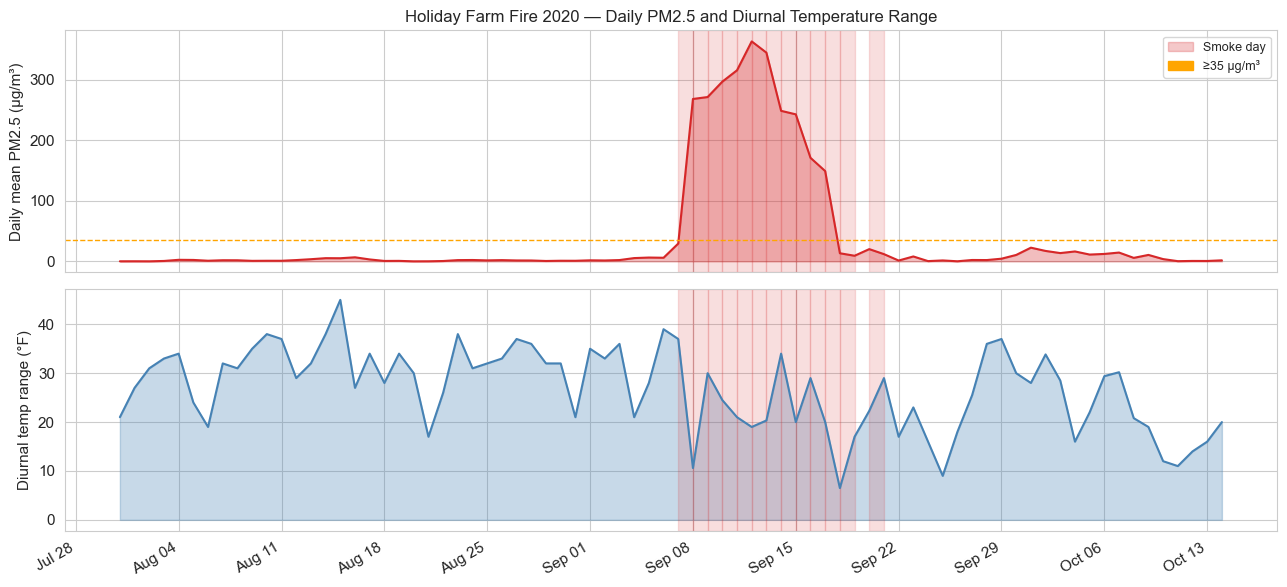

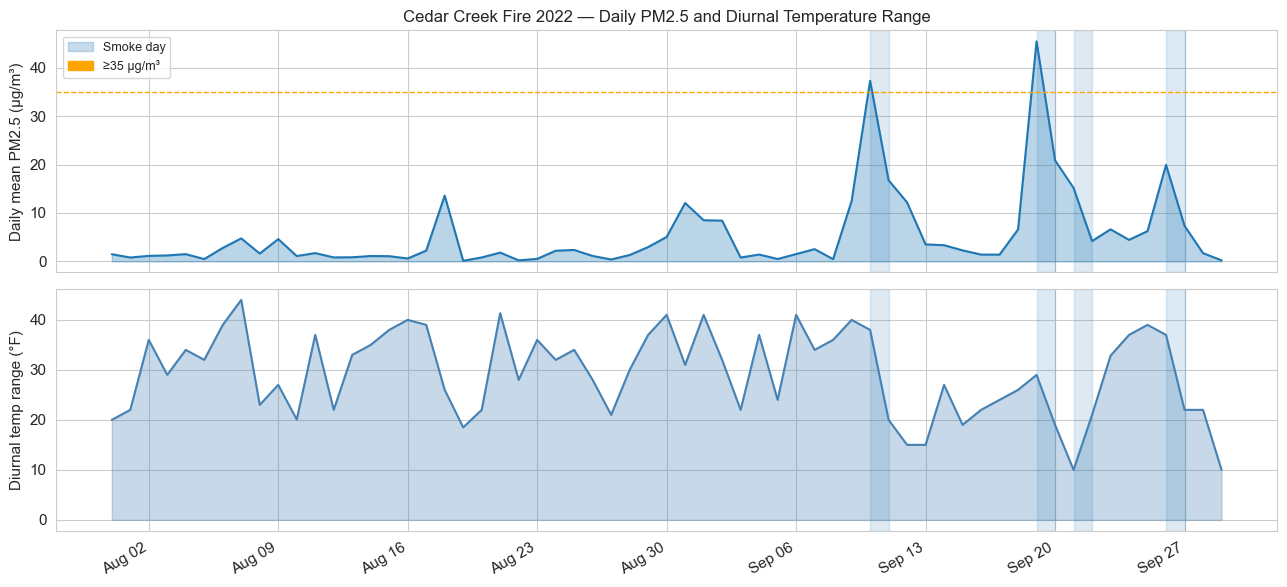

In [3]:
for ev_name, ev_daily, color in [
    ('Holiday Farm Fire 2020', d2020, COLOR_2020),
    ('Cedar Creek Fire 2022',  d2022, COLOR_2022),
]:
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

    ax = axes[0]
    ax.fill_between(ev_daily['date_dt'], ev_daily['pm_mean'], alpha=0.3, color=color)
    ax.plot(ev_daily['date_dt'], ev_daily['pm_mean'], color=color, linewidth=1.5)
    ax.axhline(SMOKE_THRESHOLD, color='orange', linestyle='--', linewidth=1,
               label=f'Smoke threshold ({SMOKE_THRESHOLD} µg/m³)')
    ax.set_ylabel('Daily mean PM2.5 (µg/m³)')
    ax.legend(fontsize=9)

    ax = axes[1]
    ax.fill_between(ev_daily['date_dt'], ev_daily['dtr'], alpha=0.3, color='steelblue')
    ax.plot(ev_daily['date_dt'], ev_daily['dtr'], color='steelblue', linewidth=1.5)
    ax.set_ylabel('Diurnal temp range (°F)')

    # Shade smoke days
    for _, row in ev_daily[ev_daily['is_smoke']].iterrows():
        for a in axes:
            a.axvspan(row['date_dt'], row['date_dt'] + pd.Timedelta(days=1),
                      alpha=0.15, color=color)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    smoke_patch = mpatches.Patch(color=color, alpha=0.25, label='Smoke day')
    axes[0].legend(handles=[smoke_patch,
                             mpatches.Patch(color='orange', label=f'≥{SMOKE_THRESHOLD} µg/m³')],
                   fontsize=9)
    axes[0].set_title(f'{ev_name} — Daily PM2.5 and Diurnal Temperature Range',
                      fontsize=12)
    plt.tight_layout()
    safe = ev_name.replace(' ', '_').lower()
    plt.savefig(f'../data/processed/fig_dtr_timeseries_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. Smoke vs clean day DTR distributions

Statistical comparison with Welch's t-test. Primary focus on 2020 (sufficient power).

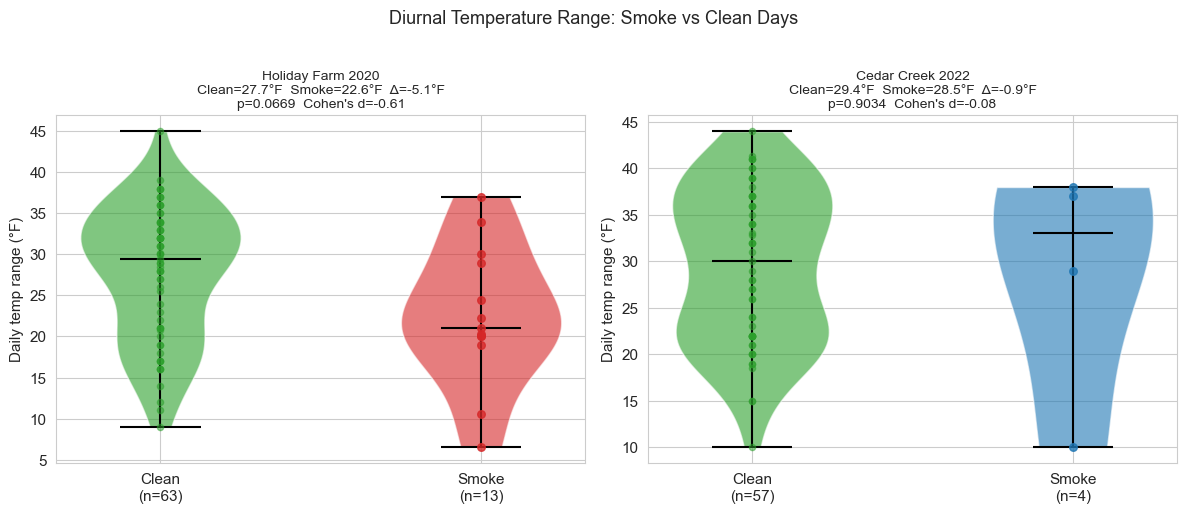

2020 smoke vs clean DTR:
  Clean: mean=27.7  std=8.1  n=63
  Smoke: mean=22.6  std=8.5  n=13
  Δ = -5.1°F
  Welch t=-1.959  p=0.0669
  Cohen's d = -0.61


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (ev_name, ev_daily, color) in zip(axes, [
    ('Holiday Farm 2020', d2020, COLOR_2020),
    ('Cedar Creek 2022',  d2022, COLOR_2022),
]):
    smoke_dtr = ev_daily[ev_daily['is_smoke']]['dtr']
    clean_dtr = ev_daily[~ev_daily['is_smoke']]['dtr']

    t, p = stats.ttest_ind(smoke_dtr, clean_dtr, equal_var=False)
    cohens_d = (smoke_dtr.mean() - clean_dtr.mean()) / np.sqrt(
        (smoke_dtr.std()**2 + clean_dtr.std()**2) / 2
    )

    vp = ax.violinplot([clean_dtr, smoke_dtr], positions=[0, 1],
                       showmedians=True, showextrema=True)
    vp['bodies'][0].set_facecolor(COLOR_CLEAN)
    vp['bodies'][0].set_alpha(0.6)
    vp['bodies'][1].set_facecolor(color)
    vp['bodies'][1].set_alpha(0.6)
    for part in ['cbars','cmins','cmaxes','cmedians']:
        vp[part].set_color('black')

    ax.scatter([0]*len(clean_dtr), clean_dtr, alpha=0.5, s=20,
               color=COLOR_CLEAN, zorder=3)
    ax.scatter([1]*len(smoke_dtr), smoke_dtr, alpha=0.8, s=30,
               color=color, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Clean\n(n={len(clean_dtr)})', f'Smoke\n(n={len(smoke_dtr)})'])
    ax.set_ylabel('Daily temp range (°F)')
    ax.set_title(
        f'{ev_name}\n'
        f'Clean={clean_dtr.mean():.1f}°F  Smoke={smoke_dtr.mean():.1f}°F  '
        f'Δ={smoke_dtr.mean()-clean_dtr.mean():+.1f}°F\n'
        f'p={p:.4f}  Cohen\'s d={cohens_d:.2f}',
        fontsize=10
    )

plt.suptitle('Diurnal Temperature Range: Smoke vs Clean Days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_dtr_smoke_vs_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# Print full stats
print('2020 smoke vs clean DTR:')
s20, c20 = d2020[d2020['is_smoke']]['dtr'], d2020[~d2020['is_smoke']]['dtr']
t, p = stats.ttest_ind(s20, c20, equal_var=False)
print(f'  Clean: mean={c20.mean():.1f}  std={c20.std():.1f}  n={len(c20)}')
print(f'  Smoke: mean={s20.mean():.1f}  std={s20.std():.1f}  n={len(s20)}')
print(f'  Δ = {s20.mean()-c20.mean():+.1f}°F')
print(f'  Welch t={t:.3f}  p={p:.4f}')
print(f'  Cohen\'s d = {(s20.mean()-c20.mean())/np.sqrt((s20.std()**2+c20.std()**2)/2):.2f}')

## 3. Scatter: daily mean PM2.5 vs DTR

Linear relationship between smoke load and DTR compression.

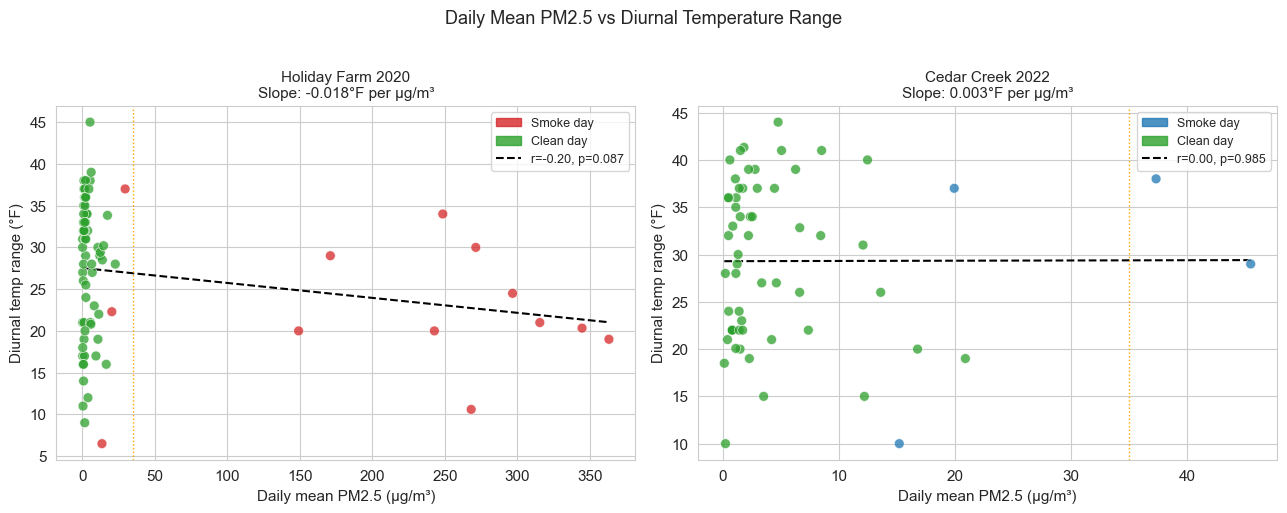

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (ev_name, ev_daily, color) in zip(axes, [
    ('Holiday Farm 2020', d2020, COLOR_2020),
    ('Cedar Creek 2022',  d2022, COLOR_2022),
]):
    r, p = stats.pearsonr(ev_daily['pm_mean'], ev_daily['dtr'])
    m, b, *_ = stats.linregress(ev_daily['pm_mean'], ev_daily['dtr'])

    ax.scatter(ev_daily['pm_mean'], ev_daily['dtr'],
               c=ev_daily['is_smoke'].map({True: color, False: COLOR_CLEAN}),
               s=50, alpha=0.75, zorder=3, edgecolors='white', linewidth=0.5)
    x_line = np.linspace(ev_daily['pm_mean'].min(), ev_daily['pm_mean'].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, label=f'r={r:.2f}, p={p:.3f}')
    ax.axvline(SMOKE_THRESHOLD, color='orange', linestyle=':', linewidth=1)

    smoke_p = mpatches.Patch(color=color,      alpha=0.8, label='Smoke day')
    clean_p = mpatches.Patch(color=COLOR_CLEAN, alpha=0.8, label='Clean day')
    ax.legend(handles=[smoke_p, clean_p,
                        plt.Line2D([],[], color='k', linestyle='--',
                                   label=f'r={r:.2f}, p={p:.3f}')],
              fontsize=9)
    ax.set_xlabel('Daily mean PM2.5 (µg/m³)')
    ax.set_ylabel('Diurnal temp range (°F)')
    ax.set_title(f'{ev_name}\nSlope: {m:.3f}°F per µg/m³', fontsize=11)

plt.suptitle('Daily Mean PM2.5 vs Diurnal Temperature Range', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_dtr_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hour-of-day temperature profiles: smoke vs clean days (2020)

If radiation suppression is the mechanism, we expect smoke days to be **cooler in the afternoon**
(peak solar hours) but **similar or warmer overnight** — producing the narrowed DTR.

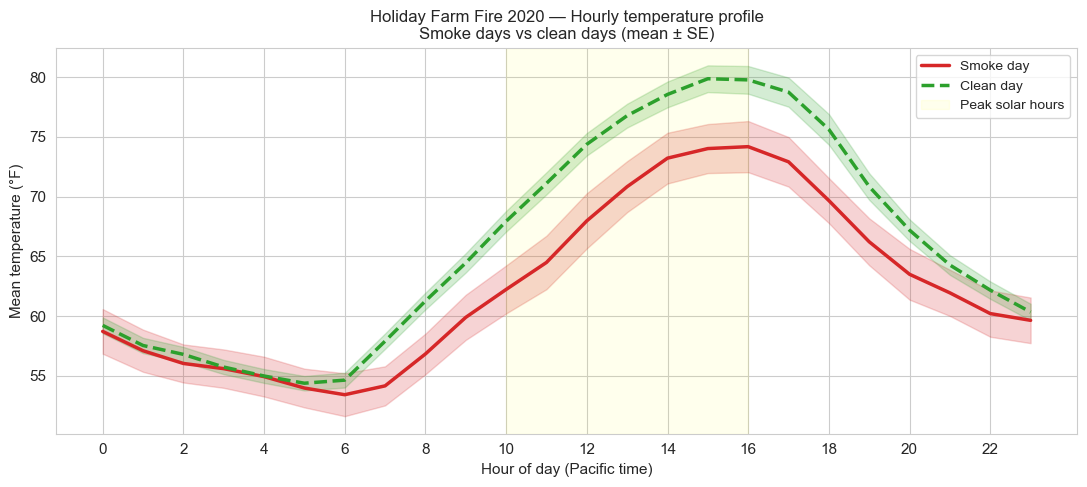

Smoke day: afternoon=72.0°F  overnight=56.1°F  spread=16.0°F
Clean day: afternoon=77.9°F  overnight=56.4°F  spread=21.4°F


In [6]:
df2020 = df[df['event'] == 'Holiday Farm Fire 2020'].copy()
smoke_dates = set(d2020[d2020['is_smoke']]['date'])
df2020['day_type'] = df2020['date'].apply(
    lambda d: 'Smoke day' if d in smoke_dates else 'Clean day'
)

hourly = df2020.groupby(['hour', 'day_type'])['temperature_f'].agg(['mean','sem']).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))

for day_type, color, ls in [
    ('Smoke day', COLOR_SMOKE, '-'),
    ('Clean day', COLOR_CLEAN, '--'),
]:
    sub = hourly[hourly['day_type'] == day_type]
    ax.fill_between(sub['hour'],
                    sub['mean'] - sub['sem'],
                    sub['mean'] + sub['sem'],
                    alpha=0.2, color=color)
    ax.plot(sub['hour'], sub['mean'], color=color, linewidth=2.5,
            linestyle=ls, label=day_type)

ax.axvspan(10, 16, alpha=0.07, color='yellow', label='Peak solar hours')
ax.set_xlabel('Hour of day (Pacific time)')
ax.set_ylabel('Mean temperature (°F)')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=10)
ax.set_title(
    'Holiday Farm Fire 2020 — Hourly temperature profile\n'
    'Smoke days vs clean days (mean ± SE)',
    fontsize=12
)

plt.tight_layout()
plt.savefig('../data/processed/fig_dtr_hourly_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# Print afternoon vs overnight difference
for day_type in ['Smoke day', 'Clean day']:
    sub = df2020[df2020['day_type'] == day_type]
    afternoon = sub[sub['hour'].between(12, 16)]['temperature_f'].mean()
    overnight = sub[sub['hour'].between(0, 5)]['temperature_f'].mean()
    print(f"{day_type}: afternoon={afternoon:.1f}°F  overnight={overnight:.1f}°F  "
          f"spread={afternoon-overnight:.1f}°F")

## 5. Case study: Sep 7–13, 2020 — peak smoke week

The most extreme week in the dataset. AQI reached 457 on Sep 13.
A detailed hourly meteogram shows the co-evolution of PM2.5 and temperature.

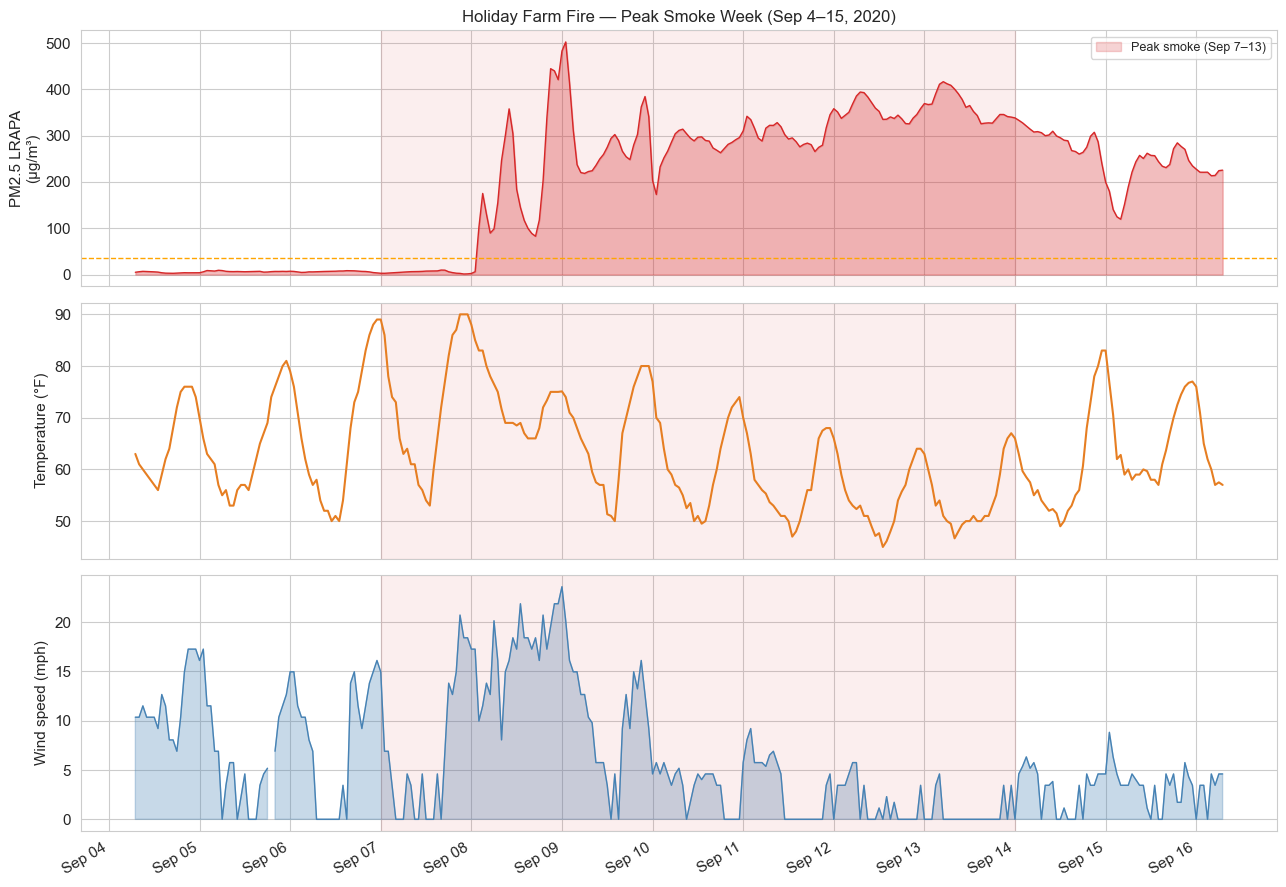

Peak smoke week (Sep 7–13):
  Mean PM2.5: 269.8  max: 502.5 µg/m³
  Mean temp:  62.1°F
  Mean wind:  6.1 mph

Pre-fire baseline (Aug 1–14):
  Mean PM2.5: 1.8 µg/m³
  Mean temp:  68.5°F
  Mean wind:  7.6 mph


In [7]:
peak = df2020[
    (df2020['timestamp'] >= '2020-09-04') &
    (df2020['timestamp'] <= '2020-09-16')
].copy()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# PM2.5
ax = axes[0]
ax.fill_between(peak['timestamp'], peak['pm2.5_lrapa'], alpha=0.3, color=COLOR_2020)
ax.plot(peak['timestamp'], peak['pm2.5_lrapa'], color=COLOR_2020, linewidth=1)
ax.axhline(SMOKE_THRESHOLD, color='orange', linestyle='--', linewidth=1)
ax.set_ylabel('PM2.5 LRAPA\n(µg/m³)')
ax.set_title('Holiday Farm Fire — Peak Smoke Week (Sep 4–15, 2020)', fontsize=12)

# Temperature
ax = axes[1]
ax.plot(peak['timestamp'], peak['temperature_f'], color='#e67e22', linewidth=1.5)
ax.set_ylabel('Temperature (°F)')

# Wind speed
ax = axes[2]
ax.fill_between(peak['timestamp'], peak['wind_speed_mph'], alpha=0.3, color='steelblue')
ax.plot(peak['timestamp'], peak['wind_speed_mph'], color='steelblue', linewidth=1)
ax.set_ylabel('Wind speed (mph)')

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-09-07'), pd.Timestamp('2020-09-14'),
               alpha=0.08, color=COLOR_2020)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

peak_patch = mpatches.Patch(color=COLOR_2020, alpha=0.2, label='Peak smoke (Sep 7–13)')
axes[0].legend(handles=[peak_patch], fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_dtr_case_study_2020.png', dpi=150, bbox_inches='tight')
plt.show()

# Peak week stats
peak_week = peak[(peak['timestamp'] >= '2020-09-07') & (peak['timestamp'] < '2020-09-14')]
pre_week  = df2020[(df2020['timestamp'] >= '2020-08-01') & (df2020['timestamp'] < '2020-08-15')]
print('Peak smoke week (Sep 7–13):')
print(f'  Mean PM2.5: {peak_week["pm2.5_lrapa"].mean():.1f}  max: {peak_week["pm2.5_lrapa"].max():.1f} µg/m³')
print(f'  Mean temp:  {peak_week["temperature_f"].mean():.1f}°F')
print(f'  Mean wind:  {peak_week["wind_speed_mph"].mean():.1f} mph')
print('\nPre-fire baseline (Aug 1–14):')
print(f'  Mean PM2.5: {pre_week["pm2.5_lrapa"].mean():.1f} µg/m³')
print(f'  Mean temp:  {pre_week["temperature_f"].mean():.1f}°F')
print(f'  Mean wind:  {pre_week["wind_speed_mph"].mean():.1f} mph')

## 6. GAM: DTR ~ s(daily mean PM2.5) + s(day of year)

A nonlinear model on the **daily** panel for 2020 only (2022 has too few smoke days).
Controls for seasonal trend via `s(dayofyear)`. The partial effect of PM2.5 is the
estimated change in DTR for a given PM2.5 level, holding season constant.

GAM fitted successfully
  Smoothing λ: PM2.5=1000.000  day-of-year=1000.000
  In-sample R² = 0.271

Note: pygam p-values are not reliable when λ is estimated by grid search.
Inference for the PM2.5 effect is based on the Welch t-test (Section 2)
and Pearson r (Section 3), which do not have this limitation.


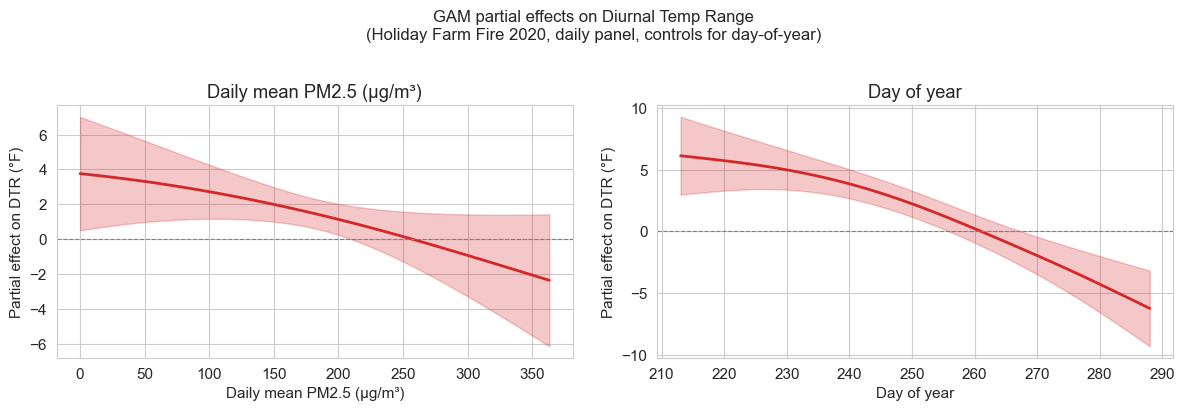

In [8]:
from pygam import LinearGAM, s
import warnings

d20 = d2020.copy()
d20['dayofyear'] = d20['date_dt'].dt.dayofyear
gam_df = d20[['pm_mean', 'dayofyear', 'dtr']].dropna()

X = gam_df[['pm_mean', 'dayofyear']].values
y = gam_df['dtr'].values

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    gam = LinearGAM(s(0) + s(1)).gridsearch(X, y, progress=False)

y_pred = gam.predict(X)
r2 = r2_score(y, y_pred)

# pygam p-values are unreliable when smoothing parameters are estimated
# (known bug: github.com/dswah/pyGAM/issues/163). Report shape and fit only.
lam_vals = np.array(gam.lam).flatten()
print(f'GAM fitted successfully')
print(f'  Smoothing λ: PM2.5={lam_vals[0]:.3f}  day-of-year={lam_vals[1]:.3f}')
print(f'  In-sample R² = {r2:.3f}')
print()
print('Note: pygam p-values are not reliable when λ is estimated by grid search.')
print('Inference for the PM2.5 effect is based on the Welch t-test (Section 2)')
print('and Pearson r (Section 3), which do not have this limitation.')

# Partial effect of PM2.5 (term 0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (ax, label) in enumerate(zip(axes, ['Daily mean PM2.5 (µg/m³)', 'Day of year'])):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.25, color=COLOR_2020)
    ax.plot(XX[:, i], pdep, color=COLOR_2020, linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(label)
    ax.set_ylabel('Partial effect on DTR (°F)')
    ax.set_title(label)

plt.suptitle('GAM partial effects on Diurnal Temp Range\n'
             '(Holiday Farm Fire 2020, daily panel, controls for day-of-year)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_dtr_gam.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

Key numbers for the thesis results section:

In [9]:
s20 = d2020[d2020['is_smoke']]['dtr']
c20 = d2020[~d2020['is_smoke']]['dtr']
t, p = stats.ttest_ind(s20, c20, equal_var=False)
cohens_d = (s20.mean() - c20.mean()) / np.sqrt((s20.std()**2 + c20.std()**2) / 2)
r_daily, p_daily = stats.pearsonr(d2020['pm_mean'], d2020['dtr'])

print('=' * 60)
print('DIURNAL TEMPERATURE RANGE — Holiday Farm Fire 2020')
print('=' * 60)
print(f'Total days:           {len(d2020)}')
print(f'Smoke days (≥35):     {len(s20)}')
print(f'Clean days:           {len(c20)}')
print()
print(f'Clean day DTR mean:   {c20.mean():.1f}°F  (SD={c20.std():.1f})')
print(f'Smoke day DTR mean:   {s20.mean():.1f}°F  (SD={s20.std():.1f})')
print(f'Difference:           {s20.mean()-c20.mean():+.1f}°F')
print(f'Welch t-test:         t={t:.3f}, p={p:.4f}')
print(f"Cohen's d:            {cohens_d:.2f}  (medium-large effect)")
print()
print(f'Daily r(PM2.5, DTR):  {r_daily:.3f}  p={p_daily:.4f}')
print()
print('Interpretation: Smoke days had a ~5°F narrower diurnal range,'
      ' consistent with solar radiation suppression by aerosols.')

DIURNAL TEMPERATURE RANGE — Holiday Farm Fire 2020
Total days:           76
Smoke days (≥35):     13
Clean days:           63

Clean day DTR mean:   27.7°F  (SD=8.1)
Smoke day DTR mean:   22.6°F  (SD=8.5)
Difference:           -5.1°F
Welch t-test:         t=-1.959, p=0.0669
Cohen's d:            -0.61  (medium-large effect)

Daily r(PM2.5, DTR):  -0.198  p=0.0867

Interpretation: Smoke days had a ~5°F narrower diurnal range, consistent with solar radiation suppression by aerosols.
